# Task 0 - Exploratory Data Analysis
**BUSI97075-2526 | Applied Trading Strategies**

## Purpose

Before building any strategy, we need to understand the raw data: what we have, how long each series runs, whether the universe is consistent, and what the statistical properties look like. EDA answers three questions:

1. **Can we trust the data?** - Check for gaps, misalignments, and missing series.
2. **What does passive exposure look like?** - Build an equally-weighted benchmark. Any active strategy must beat it to justify its complexity.
3. **What should we expect to exploit?** - Sector structure, pairwise correlations, and distributional properties all inform signal design in Tasks 1-3.

## Outputs produced by this notebook

| File | Purpose |
|-|-|
| `data/training/returns.csv` | The only file strategy code should read during development |
| `data/testing/returns.csv` | Sealed until final out-of-sample evaluation - do not open early |
| `data/raw/` | Full unaligned history; archival only |

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# -- plot style ------------------------------------------------------------
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid']  = True
plt.rcParams['grid.alpha'] = 0.3

# -- file paths (relative to tasks/ folder) -------------------------------
COMDTY_FILE   = '../source/Commodities Data thru 18May26.xlsx'
DATA_RAW      = '../data/raw'
DATA_TRAINING = '../data/training'
DATA_TESTING  = '../data/testing'

# -- train/test split -----------------------------------------------------
# These dates are fixed for the entire project and must never be changed.
# Cutting at end-of-2019 means the test set begins with COVID (Jan 2020),
# which was entirely unseen during model design - no look-ahead bias.
TRAIN_END  = '2019-12-31'
TEST_START = '2020-01-01'

## 1. Load Raw Data

The source file contains three sheets:

- **Rebased**: daily price index levels for 23 commodity futures, going back as far as 1969. Used for archival storage in `data/raw/`.
- **Returns**: daily *percentage* returns, pre-computed. Loaded directly — no `pct_change()` needed.

We intentionally **keep NaN values** at this stage. Different commodities started trading at different times, so earlier rows will be incomplete. The commodity metadata (name and sector) is hardcoded from the fixed 23-instrument universe since the new file no longer ships an Assets sheet.

In [40]:
xl = pd.ExcelFile(COMDTY_FILE)

# New file has no 'Assets' sheet — build the metadata from the fixed 23-commodity
# universe. Column order in the sheet is unchanged; only expiry tickers updated.
COMMODITY_META = [
    ('LIVE CATTLE',   'Agri & livestock'),
    ('LEAN HOGS',     'Agri & livestock'),
    ("COFFEE 'C'",    'Agri & livestock'),
    ('CORN',          'Agri & livestock'),
    ('COTTON NO.2',   'Agri & livestock'),
    ('SOYBEAN',       'Agri & livestock'),
    ('SUGAR #11',     'Agri & livestock'),
    ('WHEAT FUTURE',  'Agri & livestock'),
    ('BRENT CRUDE',   'Energy'),
    ('COPPER FUTURE', 'Metals'),
    ('GASOLINE RBOB', 'Energy'),
    ('GOLD 100 OZ',   'Metals'),
    ('NATURAL GAS',   'Energy'),
    ('SILVER',        'Metals'),
    ('PLATINUM',      'Metals'),
    ('WTI CRUDE',     'Energy'),
    ('LME NICKEL',    'Metals'),
    ('LME COPPER',    'Metals'),
    ('LME ALUMINIUM', 'Metals'),
    ('LME LEAD',      'Metals'),
    ('LME ZINC',      'Metals'),
    ('COCOA',         'Agri & livestock'),
    ('HEATING OIL',   'Energy'),
]

# Rebased sheet = price index levels (archival; saved to data/raw/).
idx = pd.read_excel(xl, sheet_name='Rebased', index_col=0, parse_dates=True)
idx.index = pd.to_datetime(idx.index, errors='coerce')
idx = idx[idx.index.notna()].sort_index()
idx.index.name = 'Date'

# Returns sheet already contains daily % returns — no pct_change() needed.
# The first row is NaN by construction (no prior day to diff against); drop it.
rets_raw = pd.read_excel(xl, sheet_name='Returns', index_col=0, parse_dates=True)
rets_raw.index = pd.to_datetime(rets_raw.index, errors='coerce')
rets_raw = rets_raw[rets_raw.index.notna()].sort_index()
rets_raw.index.name = 'Date'
rets_raw = rets_raw.iloc[1:]

# Attach column names to the metadata so every downstream cell can look up
# sector / short name by ColName.
assets = pd.DataFrame(COMMODITY_META, columns=['Commodity', 'Sector'])
assets['ColName'] = rets_raw.columns.tolist()

print(f'Raw date range : {rets_raw.index[0].date()} -> {rets_raw.index[-1].date()}')
print(f'Total rows     : {len(rets_raw):,}')
print(f'Commodities    : {rets_raw.shape[1]}')
assets

Raw date range : 1969-01-02 -> 2026-05-18
Total rows     : 14,968
Commodities    : 23


,Commodity,Sector,ColName
0,LIVE CATTLE,Agri & livestock,LIVE CATTLE FUTR Aug26
1,LEAN HOGS,Agri & livestock,LEAN HOGS FUTURE Jul26
2,COFFEE 'C',Agri & livestock,COFFEE 'C' FUTURE Jul26
3,CORN,Agri & livestock,CORN FUTURE Jul26
4,COTTON NO.2,Agri & livestock,COTTON NO.2 FUTR Jul26
5,SOYBEAN,Agri & livestock,SOYBEAN FUTURE Jul26
6,SUGAR #11,Agri & livestock,SUGAR #11 (WORLD) Jul26
7,WHEAT FUTURE,Agri & livestock,WHEAT FUTURE(CBT) Jul26
8,BRENT CRUDE,Energy,BRENT CRUDE FUTR Jul26
9,COPPER FUTURE,Metals,COPPER FUTURE Jul26


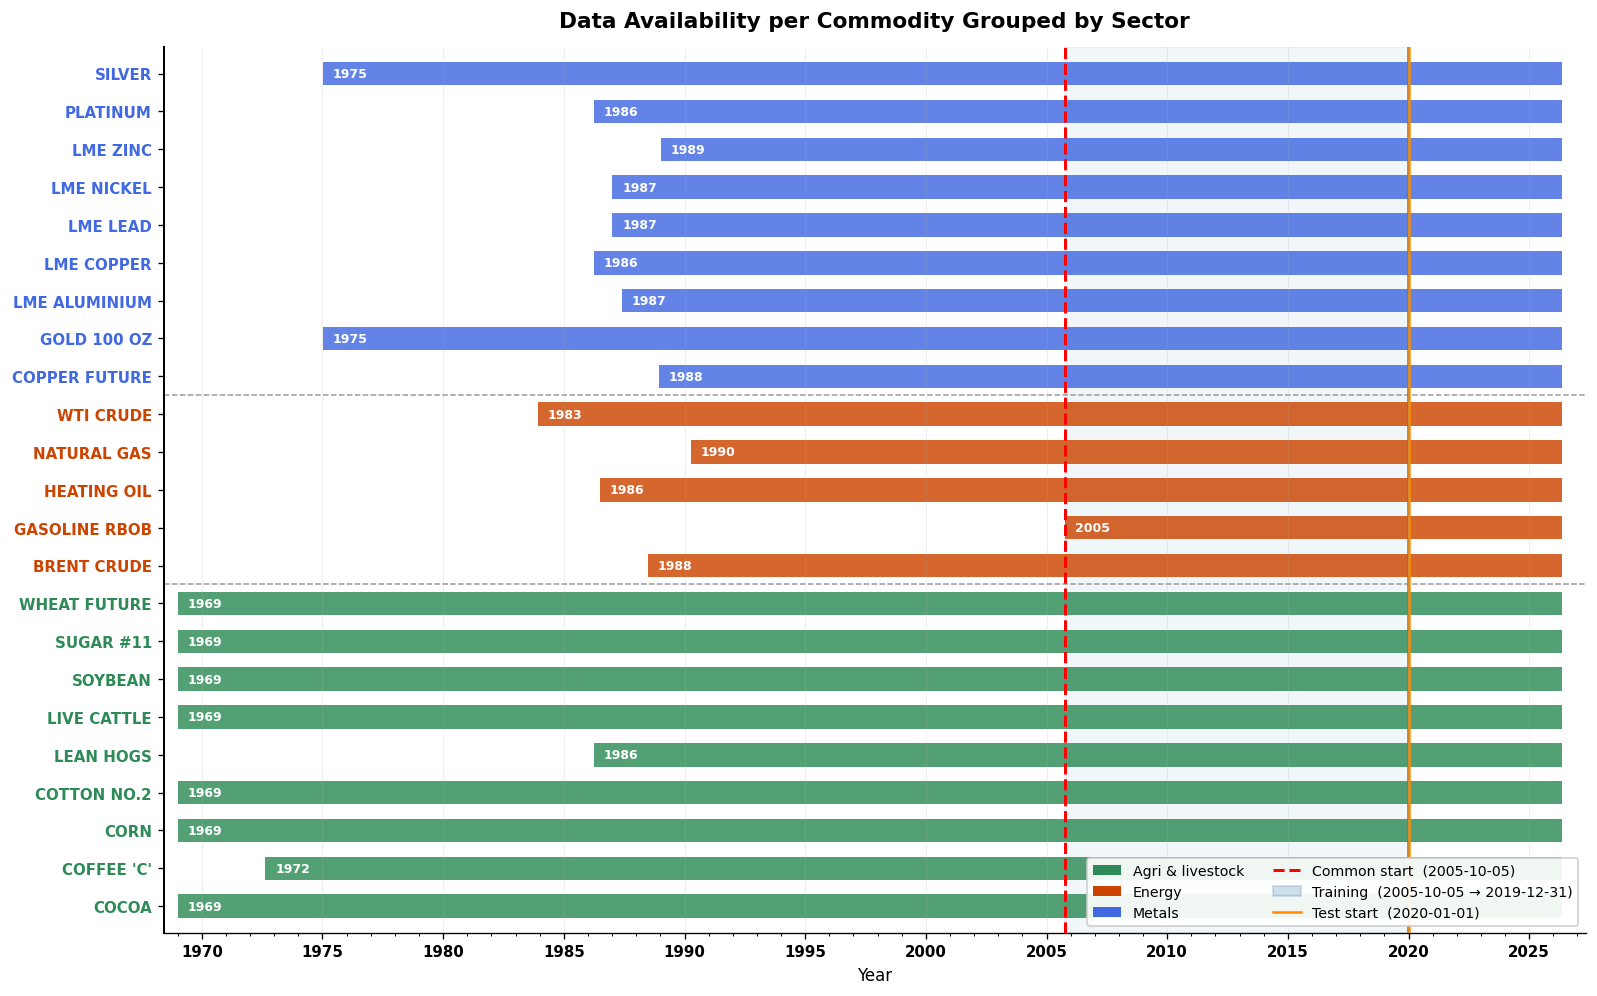

Common start : 2005-10-05
Training     : 2005-10-05 → 2019-12-31
Test         : 2020-01-01 → 2026-05-18


In [41]:
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

sector_colours = {
    'Agri & livestock': '#2e8b57',
    'Energy'          : '#cc4400',
    'Metals'          : '#4169e1',
}

# First and last valid date per commodity.
starts = rets_raw.apply(lambda col: col.first_valid_index())
ends   = rets_raw.apply(lambda col: col.last_valid_index())
common_start_preview = starts.max()

# Sort by sector so colour blocks group visually.
sector_order  = {'Agri & livestock': 0, 'Energy': 1, 'Metals': 2}
sorted_assets = assets.copy()
sorted_assets['_sort'] = sorted_assets['Sector'].map(sector_order)
sorted_assets = sorted_assets.sort_values(['_sort', 'Commodity']).reset_index(drop=True)
n = len(sorted_assets)

# Pre-compute key date numbers once.
common_num     = mdates.date2num(common_start_preview)
train_end_num  = mdates.date2num(pd.Timestamp(TRAIN_END))
test_start_num = mdates.date2num(pd.Timestamp(TEST_START))
test_end_num   = mdates.date2num(pd.Timestamp(rets_raw.index[-1]))

fig, ax = plt.subplots(figsize=(15, 9))
fig.subplots_adjust(left=0.18, right=0.97, top=0.90, bottom=0.08)

# ── 1. Background window shading (training only) ───────────────────────────
ax.axvspan(common_num, train_end_num, color='steelblue', alpha=0.07, zorder=0)

# ── 2. Commodity bars ──────────────────────────────────────────────────────
for i, row in sorted_assets.iterrows():
    col    = row['ColName']
    s, e   = starts[col], ends[col]
    colour = sector_colours.get(row['Sector'], 'grey')
    s_num  = mdates.date2num(s)
    e_num  = mdates.date2num(e)

    ax.barh(i, e_num - s_num, left=s_num,
            color=colour, alpha=0.82, edgecolor='none', height=0.62)

    # Start year in white bold inside the bar.
    ax.text(s_num + 150, i, str(s.year),
            va='center', ha='left', fontsize=7.5,
            fontweight='bold', color='white')

# ── 3. Sector separator lines ──────────────────────────────────────────────
prev_sector = None
for i, row in sorted_assets.iterrows():
    if row['Sector'] != prev_sector and prev_sector is not None:
        ax.axhline(i - 0.5, color='#999999', linewidth=0.9,
                   linestyle='--', zorder=1)
    prev_sector = row['Sector']

# ── 4. Key vertical lines ──────────────────────────────────────────────────
ax.axvline(common_num,     color='red',        linewidth=1.8, linestyle='--', zorder=5)
ax.axvline(train_end_num,  color='steelblue',  linewidth=1.5, linestyle='-',  zorder=5)
ax.axvline(test_start_num, color='darkorange', linewidth=1.5, linestyle='-',  zorder=5)

# ── 5. Axes formatting ─────────────────────────────────────────────────────
ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.YearLocator(1))
plt.setp(ax.get_xticklabels(), fontsize=9, fontweight='bold')

ax.set_xlim(mdates.date2num(pd.Timestamp('1968-06-01')), test_end_num + 350)
ax.set_ylim(-0.7, n - 0.3)

ax.set_yticks(range(n))
ax.set_yticklabels(sorted_assets['Commodity'].tolist(), fontsize=9, fontweight='bold')
for ytick, (_, row) in zip(ax.get_yticklabels(), sorted_assets.iterrows()):
    ytick.set_color(sector_colours.get(row['Sector'], 'black'))

ax.grid(axis='x', alpha=0.20, linewidth=0.6, zorder=0)
ax.grid(axis='y', visible=False)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1.2)

# ── 6. Legend ──────────────────────────────────────────────────────────────
legend_handles = [
    Patch(facecolor=c, edgecolor='none', label=s)
    for s, c in sector_colours.items()
]
legend_handles += [
    Line2D([0], [0], color='red', linestyle='--', linewidth=1.8,
           label=f'Common start  ({common_start_preview.date()})'),
    Patch(facecolor='steelblue',  alpha=0.25, edgecolor='steelblue',
          label=f'Training  ({common_start_preview.date()} → {TRAIN_END})'),
    Line2D([0], [0], color='darkorange', linewidth=1.5,
           label=f'Test start  ({TEST_START})'),
]
ax.legend(handles=legend_handles, fontsize=8.5, loc='lower right',
          framealpha=0.92, edgecolor='#cccccc', ncol=2)

ax.set_title('Data Availability per Commodity Grouped by Sector',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=10)

plt.show()

print(f'Common start : {common_start_preview.date()}')
print(f'Training     : {common_start_preview.date()} → {TRAIN_END}')
print(f'Test         : {TEST_START} → {rets_raw.index[-1].date()}')

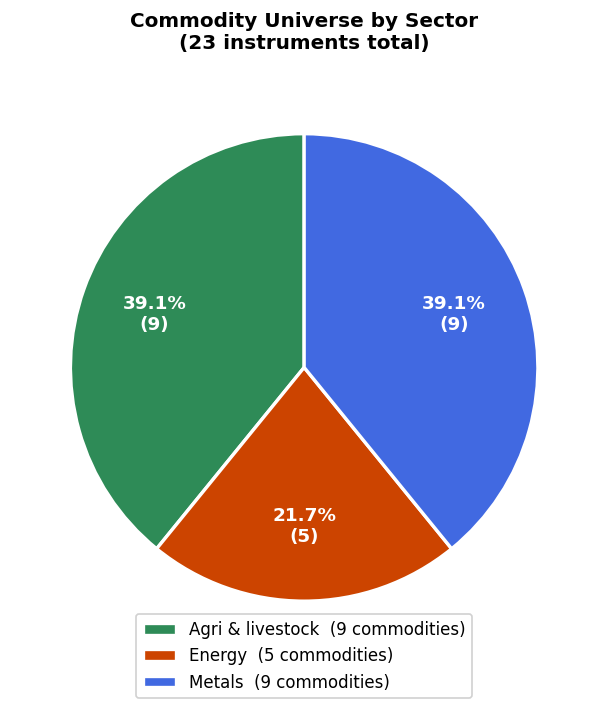

In [42]:
sector_counts = assets.groupby('Sector')['Commodity'].count()

# Match the sector colour scheme used throughout the notebook.
colours = [sector_colours[s] for s in sector_counts.index]

fig, ax = plt.subplots(figsize=(6, 6))

wedges, texts, autotexts = ax.pie(
    sector_counts,
    labels=None,                 # labels added via legend instead — avoids overlap
    colors=colours,
    autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct * sum(sector_counts) / 100))})',
    pctdistance=0.68,            # place percentage text inside the wedge
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
)

# Style the in-wedge text.
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
    t.set_color('white')

# Legend lists each sector name and its commodity count.
legend_labels = [f'{s}  ({n} commodities)' for s, n in sector_counts.items()]
ax.legend(wedges, legend_labels, fontsize=10, loc='lower center',
          bbox_to_anchor=(0.5, -0.08), framealpha=0.9, edgecolor='#cccccc')

ax.set_title('Commodity Universe by Sector\n(23 instruments total)',
             fontsize=12, fontweight='bold', pad=16)

plt.tight_layout()
plt.show()

In [43]:
# Find the date when the LAST commodity first becomes available.
# Trimming every series to start here means:
#   (a) no NaN gaps from day one of the aligned window
#   (b) the portfolio-level factor always uses the same 23 assets
# The trade-off is losing the longer history of older commodities -
# accepted because a consistent universe is essential for clean backtesting.
common_start = rets_raw.apply(lambda col: col.first_valid_index()).max()
rets = rets_raw.loc[common_start:]

print(f'Common start : {common_start.date()}')
print(f'Aligned rows : {len(rets):,}')
print(f'Training     : {common_start.date()} -> {TRAIN_END}  ({len(rets.loc[:TRAIN_END]):,} rows)')
print(f'Test         : {TEST_START} -> {rets.index[-1].date()}  ({len(rets.loc[TEST_START:]):,} rows)')
print(f'\nAny NaNs remaining: {rets.isna().any().any()}')

Common start : 2005-10-05
Aligned rows : 5,379
Training     : 2005-10-05 -> 2019-12-31  (3,715 rows)
Test         : 2020-01-01 -> 2026-05-18  (1,664 rows)

Any NaNs remaining: False


### Save Cleaned Data to `data/`

We write three separate sets of output files to enforce the **train/test discipline** at the file-system level:

- `data/training/returns.csv` - the only file any strategy code should read during development.
- `data/testing/returns.csv` - sealed until final evaluation. Opening it before then constitutes look-ahead bias.
- `data/raw/` - archival copies of the full unaligned history; useful for debugging but not used in strategy code.

Column headers are renamed from the verbose Bloomberg ticker strings (e.g. `"LIVE CATTLE FUTR  Aug25"`) to short commodity names (e.g. `"LIVE CATTLE"`) to keep downstream code readable.

In [44]:
import os

for folder in [DATA_RAW, DATA_TRAINING, DATA_TESTING]:
    os.makedirs(folder, exist_ok=True)

# Map long Bloomberg column names -> short commodity names.
# e.g. "LIVE CATTLE FUTR  Aug25" -> "LIVE CATTLE"
short_names = dict(zip(assets['ColName'], assets['Commodity']))

# -- raw: full history, unaligned ------------------------------------------
# Kept for reference and debugging - never loaded by strategy code.
idx.rename(columns=short_names).to_csv(f'{DATA_RAW}/return_indices.csv')
rets_raw.rename(columns=short_names).to_csv(f'{DATA_RAW}/returns_unaligned.csv')
assets.to_csv(f'{DATA_RAW}/assets.csv', index=False)

# -- training: aligned returns up to end of 2019 ---------------------------
# This is the dataset all Tasks 1-3 read for strategy design and parameter tuning.
train = rets.loc[:TRAIN_END].rename(columns=short_names)
train.to_csv(f'{DATA_TRAINING}/returns.csv')

# -- testing: aligned returns from Jan 2020 onwards ------------------------
# Do not open this file until the final out-of-sample evaluation.
test = rets.loc[TEST_START:].rename(columns=short_names)
test.to_csv(f'{DATA_TESTING}/returns.csv')

print('Saved:')
print(f'  {DATA_RAW}/return_indices.csv       {idx.shape[0]:,} rows × {idx.shape[1]} cols')
print(f'  {DATA_RAW}/returns_unaligned.csv    {rets_raw.shape[0]:,} rows × {rets_raw.shape[1]} cols')
print(f'  {DATA_RAW}/assets.csv               {len(assets)} rows')
print(f'  {DATA_TRAINING}/returns.csv         {len(train):,} rows  ({train.index[0].date()} -> {train.index[-1].date()})')
print(f'  {DATA_TESTING}/returns.csv          {len(test):,} rows  ({test.index[0].date()} -> {test.index[-1].date()})')

Saved:
  ../data/raw/return_indices.csv       14,969 rows × 23 cols
  ../data/raw/returns_unaligned.csv    14,968 rows × 23 cols
  ../data/raw/assets.csv               23 rows
  ../data/training/returns.csv         3,715 rows  (2005-10-05 -> 2019-12-31)
  ../data/testing/returns.csv          1,664 rows  (2020-01-01 -> 2026-05-18)


## 2. Per-Commodity Summary Statistics

We compute the following metrics for each commodity over the full aligned history. Each one answers a specific question relevant to strategy design:

| Metric | What it tells us |
|-|-|
| **Ann. Mean %** | Expected return from a passive long position in this commodity |
| **Ann. Vol %** | How much daily returns vary - the key input to position sizing |
| **Sharpe Ratio** | Return per unit of risk - the primary ranking metric across assets |
| **Skewness** | Asymmetry: negative = more large losses than large gains (bad for momentum) |
| **Excess Kurtosis** | Fat tails: values > 0 mean extreme moves are more common than normal - risk models will understate tail losses |
| **Max DD %** | Worst peak-to-trough loss - sets expectations for drawdown controls in Task 2 |
| **Corr w/ EW** | How much this commodity moves with the market factor - high = less diversification value |

The EW factor is computed here first so it can serve as the correlation benchmark column.

In [45]:
def max_drawdown(s):
    # Compute the worst peak-to-trough loss at any point in the series.
    # cummax() tracks the rolling high-water mark; the drawdown at each
    # date is how far below that peak we currently sit.
    cum = (1 + s).cumprod()
    return ((cum / cum.cummax()) - 1).min()

# Pre-compute the EW factor so we can measure each commodity's
# correlation with the market as part of the same stats pass.
factor_for_stats = rets.mean(axis=1)

records = []
for col, row in zip(assets['ColName'], assets.itertuples()):
    s        = rets[col]
    ann_mean = s.mean() * 252           # scale daily mean -> annual
    ann_vol  = s.std()  * np.sqrt(252)  # scale daily std  -> annual
    sharpe   = ann_mean / ann_vol if ann_vol > 0 else np.nan
    corr_f   = s.corr(factor_for_stats)
    records.append({
        'Commodity'    : row.Commodity,
        'Sector'       : row.Sector,
        'Obs'          : len(s),
        'Ann. Mean %'  : round(ann_mean * 100, 2),
        'Ann. Vol %'   : round(ann_vol  * 100, 2),
        'Sharpe'       : round(sharpe, 3),
        'Corr w/ EW'   : round(corr_f, 3),
        'Skewness'     : round(s.skew(), 3),
        'Ex. Kurtosis' : round(s.kurtosis(), 3),
        'Max DD %'     : round(max_drawdown(s) * 100, 2),
    })

stats = pd.DataFrame(records).set_index('Commodity')

# Colour gradients make outliers immediately visible:
#   Sharpe:   green = strong risk-adjusted return, red = poor
#   Ann. Vol: deeper red = more volatile (harder to hold)
#   Corr w/EW: deeper blue = moves more with the market (less diversification benefit)
stats.style \
     .background_gradient(subset=['Sharpe'],      cmap='RdYlGn') \
     .background_gradient(subset=['Ann. Vol %'],  cmap='Reds') \
     .background_gradient(subset=['Corr w/ EW'],  cmap='Blues') \
     .format({'Ann. Mean %': '{:+.2f}', 'Ann. Vol %': '{:.2f}',
              'Sharpe': '{:.3f}', 'Corr w/ EW': '{:.3f}', 'Max DD %': '{:.2f}'})

,Sector,Obs,Ann. Mean %,Ann. Vol %,Sharpe,Corr w/ EW,Skewness,Ex. Kurtosis,Max DD %
Commodity,,,,,,,,,
LIVE CATTLE,Agri & livestock,5379,+0.60,15.19,0.039,0.245,-0.070000,2.248000,-58.44
LEAN HOGS,Agri & livestock,5379,-7.83,26.69,-0.293,0.199,0.067000,1.532000,-95.24
COFFEE 'C',Agri & livestock,5379,+3.25,31.26,0.104,0.377,0.179000,1.611000,-87.90
CORN,Agri & livestock,5379,+2.35,26.24,0.089,0.465,0.075000,2.630000,-78.77
COTTON NO.2,Agri & livestock,5379,+1.96,24.95,0.079,0.418,-0.024000,1.611000,-71.33
SOYBEAN,Agri & livestock,5379,+7.11,21.66,0.328,0.514,-0.114000,2.838000,-52.75
SUGAR #11,Agri & livestock,5379,+0.73,29.63,0.025,0.409,-0.076000,2.095000,-84.89
WHEAT FUTURE,Agri & livestock,5379,-3.78,30.88,-0.122,0.420,0.212000,1.916000,-94.70
BRENT CRUDE,Energy,5379,+9.64,35.85,0.269,0.713,-0.314000,10.455000,-91.76


### Pairwise Correlation Matrix (Training Period Only)

We restrict the correlation calculation to the **training window** (up to Dec 2019). Using the full history here would let test-period correlations influence our understanding of the universe - a subtle form of look-ahead.

Two things to look for:
- **Within-sector clustering**: energy names tend to move together; so do industrial metals. This means a momentum strategy that goes long several energy names simultaneously takes a concentrated sector bet, not 5 independent positions.
- **Near-duplicate pairs**: Copper Future (COMEX) and LME Copper both track the same metal on different exchanges. Their correlation of ~0.92 means holding both at full weight almost doubles the copper exposure - worth flagging for portfolio construction in Task 2.

In [46]:
# Compute correlations on training data only - test-period correlations stay unseen.
corr_train = rets.loc[:TRAIN_END].corr()
corr_train.index   = assets['Commodity'].tolist()
corr_train.columns = assets['Commodity'].tolist()

# Summarise the upper triangle (unique pairs only - the diagonal is always 1.0).
upper = corr_train.values[np.triu_indices_from(corr_train.values, k=1)]
print(f'Mean pairwise correlation : {upper.mean():.3f}')
print(f'Max  pairwise correlation : {upper.max():.3f}  '
      f'({corr_train.stack().loc[lambda x: x < 0.9999].idxmax()})')
print(f'Min  pairwise correlation : {upper.min():.3f}')

# Heat map: green = positive correlation, red = negative.
# The block structure (clusters of similar colour) reveals which
# commodities move together - i.e. which "independent" positions are not.
corr_train.style \
    .background_gradient(cmap='RdYlGn', vmin=-1, vmax=1) \
    .format('{:.2f}')

Mean pairwise correlation : 0.258
Max  pairwise correlation : 0.924  (('COPPER FUTURE', 'LME COPPER'))
Min  pairwise correlation : 0.020


,LIVE CATTLE,LEAN HOGS,COFFEE 'C',CORN,COTTON NO.2,SOYBEAN,SUGAR #11,WHEAT FUTURE,BRENT CRUDE,COPPER FUTURE,GASOLINE RBOB,GOLD 100 OZ,NATURAL GAS,SILVER,PLATINUM,WTI CRUDE,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA,HEATING OIL
LIVE CATTLE,1.00,0.29,0.11,0.14,0.11,0.14,0.13,0.12,0.14,0.15,0.12,0.02,0.06,0.08,0.08,0.14,0.08,0.13,0.11,0.09,0.09,0.09,0.12
LEAN HOGS,0.29,1.00,0.07,0.10,0.07,0.12,0.07,0.09,0.10,0.10,0.08,0.02,0.03,0.05,0.05,0.11,0.08,0.09,0.08,0.10,0.10,0.04,0.10
COFFEE 'C',0.11,0.07,1.00,0.20,0.20,0.24,0.28,0.20,0.21,0.22,0.17,0.17,0.09,0.22,0.22,0.22,0.18,0.21,0.19,0.17,0.19,0.19,0.19
CORN,0.14,0.10,0.20,1.00,0.29,0.64,0.24,0.65,0.26,0.25,0.23,0.18,0.11,0.23,0.20,0.26,0.20,0.23,0.21,0.17,0.19,0.13,0.25
COTTON NO.2,0.11,0.07,0.20,0.29,1.00,0.32,0.22,0.27,0.25,0.28,0.22,0.15,0.06,0.21,0.22,0.24,0.23,0.27,0.22,0.20,0.21,0.16,0.24
SOYBEAN,0.14,0.12,0.24,0.64,0.32,1.00,0.24,0.49,0.32,0.33,0.28,0.20,0.13,0.28,0.26,0.31,0.25,0.30,0.26,0.24,0.26,0.16,0.32
SUGAR #11,0.13,0.07,0.28,0.24,0.22,0.24,1.00,0.22,0.22,0.25,0.19,0.14,0.07,0.19,0.19,0.24,0.18,0.23,0.20,0.17,0.18,0.18,0.21
WHEAT FUTURE,0.12,0.09,0.20,0.65,0.27,0.49,0.22,1.00,0.23,0.22,0.20,0.16,0.09,0.20,0.18,0.22,0.17,0.21,0.18,0.15,0.17,0.14,0.21
BRENT CRUDE,0.14,0.10,0.21,0.26,0.25,0.32,0.22,0.23,1.00,0.40,0.84,0.23,0.19,0.30,0.31,0.91,0.31,0.38,0.32,0.28,0.29,0.20,0.90
COPPER FUTURE,0.15,0.10,0.22,0.25,0.28,0.33,0.25,0.22,0.40,1.00,0.36,0.36,0.09,0.46,0.42,0.41,0.59,0.92,0.62,0.60,0.68,0.21,0.37


## 3. Sector-Level Summary

Grouping the 23 commodities into their three sectors (Agri & Livestock, Energy, Metals) serves two purposes:

1. **Attribution baseline**: Task 1 requires a sector breakdown of strategy performance. Understanding baseline passive sector returns now gives us a reference point - if our momentum strategy over-weights Energy, we want to know whether Energy was a good or bad sector to be in during the training period.
2. **Risk concentration awareness**: within-sector correlations are higher than cross-sector ones, so a momentum strategy going long several Energy names simultaneously takes a concentrated bet. Knowing which sectors trend persistently (vs mean-revert) matters for signal design.

The sector return is the simple equal-weighted average across its constituent commodities - same construction as the overall EW factor, but applied within each sector.

,N Commodities,Ann. Mean %,Ann. Vol %,Sharpe
Sector,,,,
Agri & livestock,9,1.50,13.94,0.107
Energy,5,1.84,35.39,0.052
Metals,9,8.55,19.99,0.428


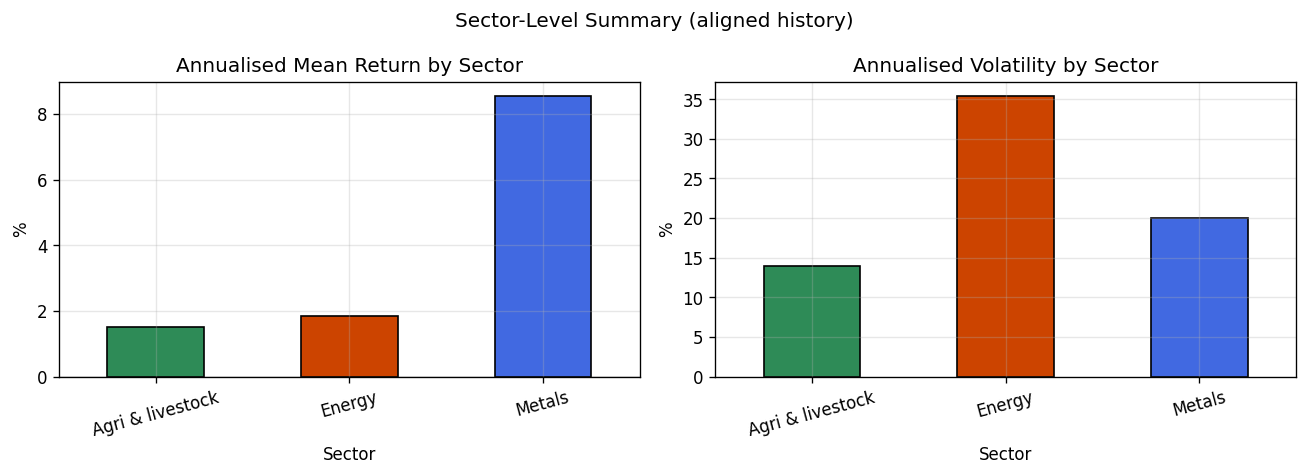

In [47]:
sector_records = []
for sector, grp in assets.groupby('Sector'):
    cols = grp['ColName'].tolist()
    # Average across the sector's commodities on each date.
    # Equal-weighting within the sector is the natural neutral baseline -
    # no prior view on which commodity within the sector is more important.
    daily    = rets[cols].mean(axis=1).dropna()
    ann_mean = daily.mean() * 252
    ann_vol  = daily.std()  * np.sqrt(252)
    sector_records.append({
        'Sector'       : sector,
        'N Commodities': len(cols),
        'Ann. Mean %'  : round(ann_mean * 100, 2),
        'Ann. Vol %'   : round(ann_vol  * 100, 2),
        'Sharpe'       : round(ann_mean / ann_vol, 3),
    })

sector_stats = pd.DataFrame(sector_records).set_index('Sector')
display(sector_stats)

# Separate bar charts for mean return and volatility so we can read
# them independently - a sector can be high-return AND high-volatility,
# which the Sharpe table collapses into a single number.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colours = ['#2e8b57', '#cc4400', '#4169e1']

sector_stats['Ann. Mean %'].plot(kind='bar', ax=axes[0], color=colours, edgecolor='black')
axes[0].axhline(0, color='black', linewidth=0.7)
axes[0].set_title('Annualised Mean Return by Sector')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=15)

sector_stats['Ann. Vol %'].plot(kind='bar', ax=axes[1], color=colours, edgecolor='black')
axes[1].set_title('Annualised Volatility by Sector')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=15)

fig.suptitle('Sector-Level Summary (aligned history)', fontsize=12)
fig.tight_layout()
plt.show()

## 4. Equally-Weighted Commodity Market Factor

The **EW factor** is the simple average daily return across all 23 commodities. It represents what a passive, long-only investor would earn by holding the full commodity complex with no views.

**Why this construction?**
- *Equally-weighted* rather than market-cap-weighted: commodity futures don't have a natural market cap, so equal weights are the standard neutral baseline in academic literature.
- *Long-only*: captures the pure passive beta. Active strategies earn alpha by deviating from this.
- *No leverage*: makes it a clean, comparable benchmark - the same notional, no amplification.

**Why report three periods separately?**
Training, test, and full-history figures help us detect regime differences. A strategy that looks good in training but the factor also did well in training tells a different story than one where the factor struggled. Note the test period (2020-2025) includes the COVID commodity crash, the 2021-2022 supercycle, and the 2022 energy crisis - unusually extreme conditions that significantly boosted the factor's test-period Sharpe.

In [48]:
# Average across all 23 commodities on each date - equal-weighted.
# .mean(axis=1) naturally handles any residual NaN values by averaging
# over available series, though after alignment there should be none.
factor = rets.mean(axis=1)
factor.name = 'CommodityFactor'

def factor_stats(s, label):
    ann_mean = s.mean() * 252
    ann_vol  = s.std()  * np.sqrt(252)
    cum      = (1 + s).cumprod()
    mdd      = ((cum / cum.cummax()) - 1).min()
    print(f'{label:<18}  Ann.Mean={ann_mean*100:+.2f}%  '
          f'Ann.Vol={ann_vol*100:.2f}%  '
          f'Sharpe={ann_mean/ann_vol:.3f}  '
          f'MaxDD={mdd*100:.2f}%')

# Reporting three windows separately exposes regime differences.
# A strategy that only performs well in a specific period is not robust.
factor_stats(factor,                  'Full history')
factor_stats(factor.loc[:TRAIN_END],  'Training')
factor_stats(factor.loc[TEST_START:], 'Test')

Full history        Ann.Mean=+4.33%  Ann.Vol=15.82%  Sharpe=0.274  MaxDD=-63.54%
Training            Ann.Mean=+1.23%  Ann.Vol=15.65%  Sharpe=0.079  MaxDD=-52.91%
Test                Ann.Mean=+11.25%  Ann.Vol=16.20%  Sharpe=0.695  MaxDD=-42.36%


## 5. Cumulative Returns - All Commodities + Market Factor

This chart overlays every commodity's cumulative return path alongside the EW factor. It is the most informative single plot in the EDA because it simultaneously shows:

- **Dispersion**: how differently individual commodities perform - some multiply several times over, others nearly wipe out.
- **Trend structure**: long, sustained moves are visible as smooth upward or downward slopes. These are the patterns a momentum strategy aims to exploit.
- **Regime breaks**: the 2008 commodity supercycle peak, the 2014-2016 energy collapse, and the 2020 COVID crash are all visible as sharp drawdowns.

**Why log scale?** On a log y-axis, equal vertical distances represent equal *percentage* moves regardless of the starting level. On a linear scale, a commodity that grew 10× would visually dominate everything else, making the other lines unreadable.

The red dashed line marks the train/test split - strategies are designed using only data to its left.

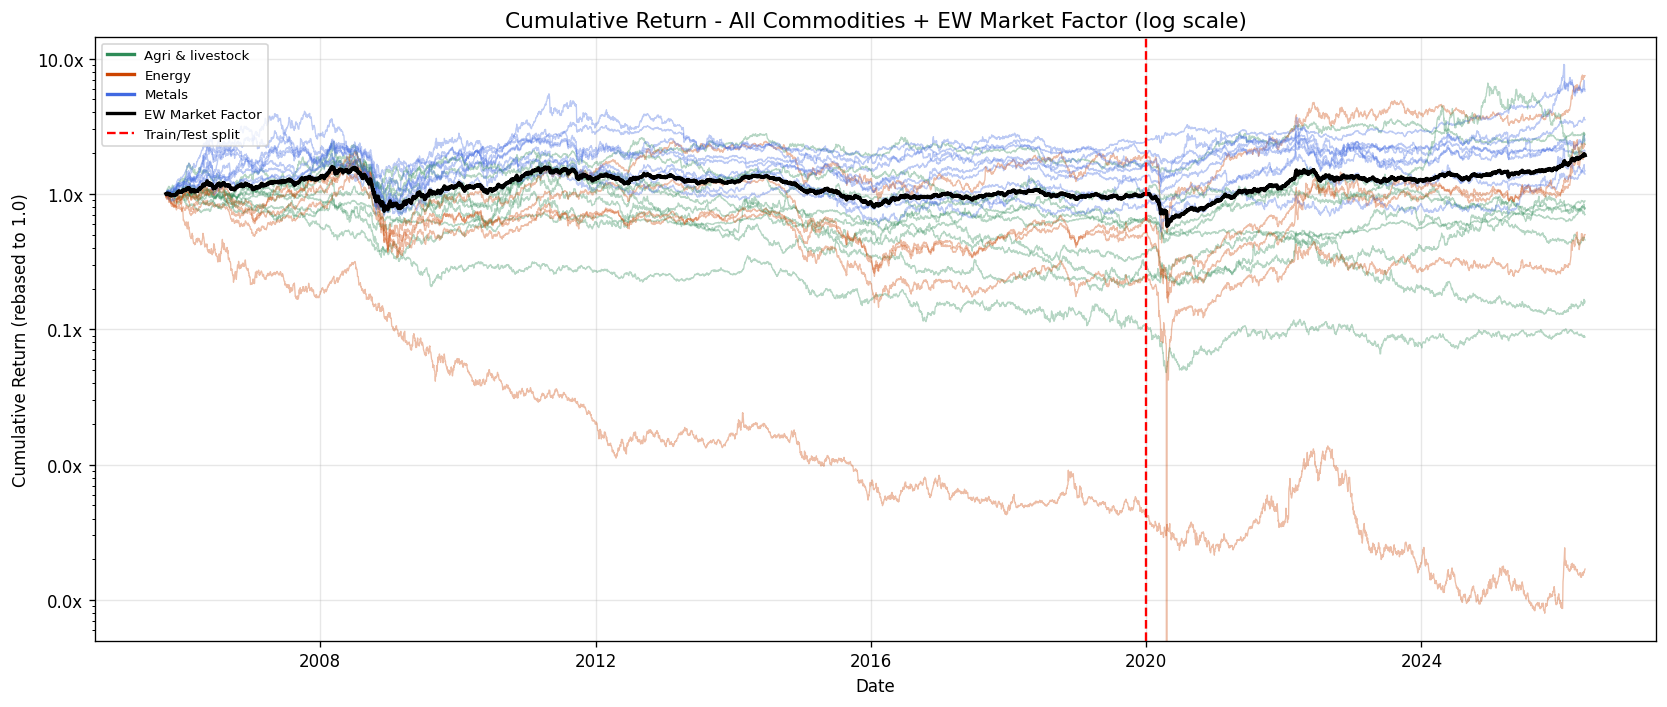

In [49]:
sector_colours = {
    'Agri & livestock': '#2e8b57',
    'Energy'          : '#cc4400',
    'Metals'          : '#4169e1',
}

fig, ax = plt.subplots(figsize=(14, 6))

# Individual commodity lines at low alpha so the overall shape of the
# universe is visible without any single series dominating the chart.
for col, row in zip(assets['ColName'], assets.itertuples()):
    s   = rets[col].dropna()
    cum = (1 + s).cumprod()
    ax.plot(cum.index, cum.values,
            color=sector_colours.get(row.Sector, 'grey'),
            alpha=0.35, linewidth=0.8)

# EW factor in bold black - this is the passive benchmark to beat.
cum_factor = (1 + factor.dropna()).cumprod()
ax.plot(cum_factor.index, cum_factor.values,
        color='black', linewidth=2.2, label='EW Market Factor')

# Train/test split marker - everything to the right is out-of-sample
# and was not used in any strategy design decision.
ax.axvline(pd.Timestamp(TRAIN_END), color='red', linestyle='--',
           linewidth=1.4, label='Train/Test split (Dec 2019)')

from matplotlib.lines import Line2D
handles = [Line2D([0],[0], color=c, linewidth=2, label=s)
           for s, c in sector_colours.items()]
handles += [
    Line2D([0],[0], color='black', linewidth=2, label='EW Market Factor'),
    Line2D([0],[0], color='red', linestyle='--', linewidth=1.4, label='Train/Test split'),
]
ax.legend(handles=handles, fontsize=8, loc='upper left')

# Log scale: equal visual height = equal percentage move.
# This makes the chart readable even when commodities differ widely in level.
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}x'))
ax.set_title('Cumulative Return - All Commodities + EW Market Factor (log scale)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (rebased to 1.0)')
fig.tight_layout()
plt.show()

## 6. Pairwise Correlation Matrix (Training Period)

The full 23×23 heatmap gives a more granular view than the summary statistics above. Three things to read off it:

1. **Block structure on the diagonal**: clusters of similar colour within a sector confirm that sector-level momentum bets are really concentrated positions, not 5 or 9 independent ones.
2. **The Copper Future / LME Copper near-duplicate** (r -> 0.92): both instruments track the same underlying metal on different exchanges. Holding both at full portfolio weight is close to doubling copper exposure - relevant for the portfolio construction step in Task 2.
3. **Low off-diagonal correlation overall**: the universe-wide mean of ~0.26 means the 23-asset universe provides genuine diversification - portfolio volatility is well below any individual commodity's.

Mean pairwise correlation : 0.258
Max pairwise correlation  : 0.924
Min pairwise correlation  : 0.020


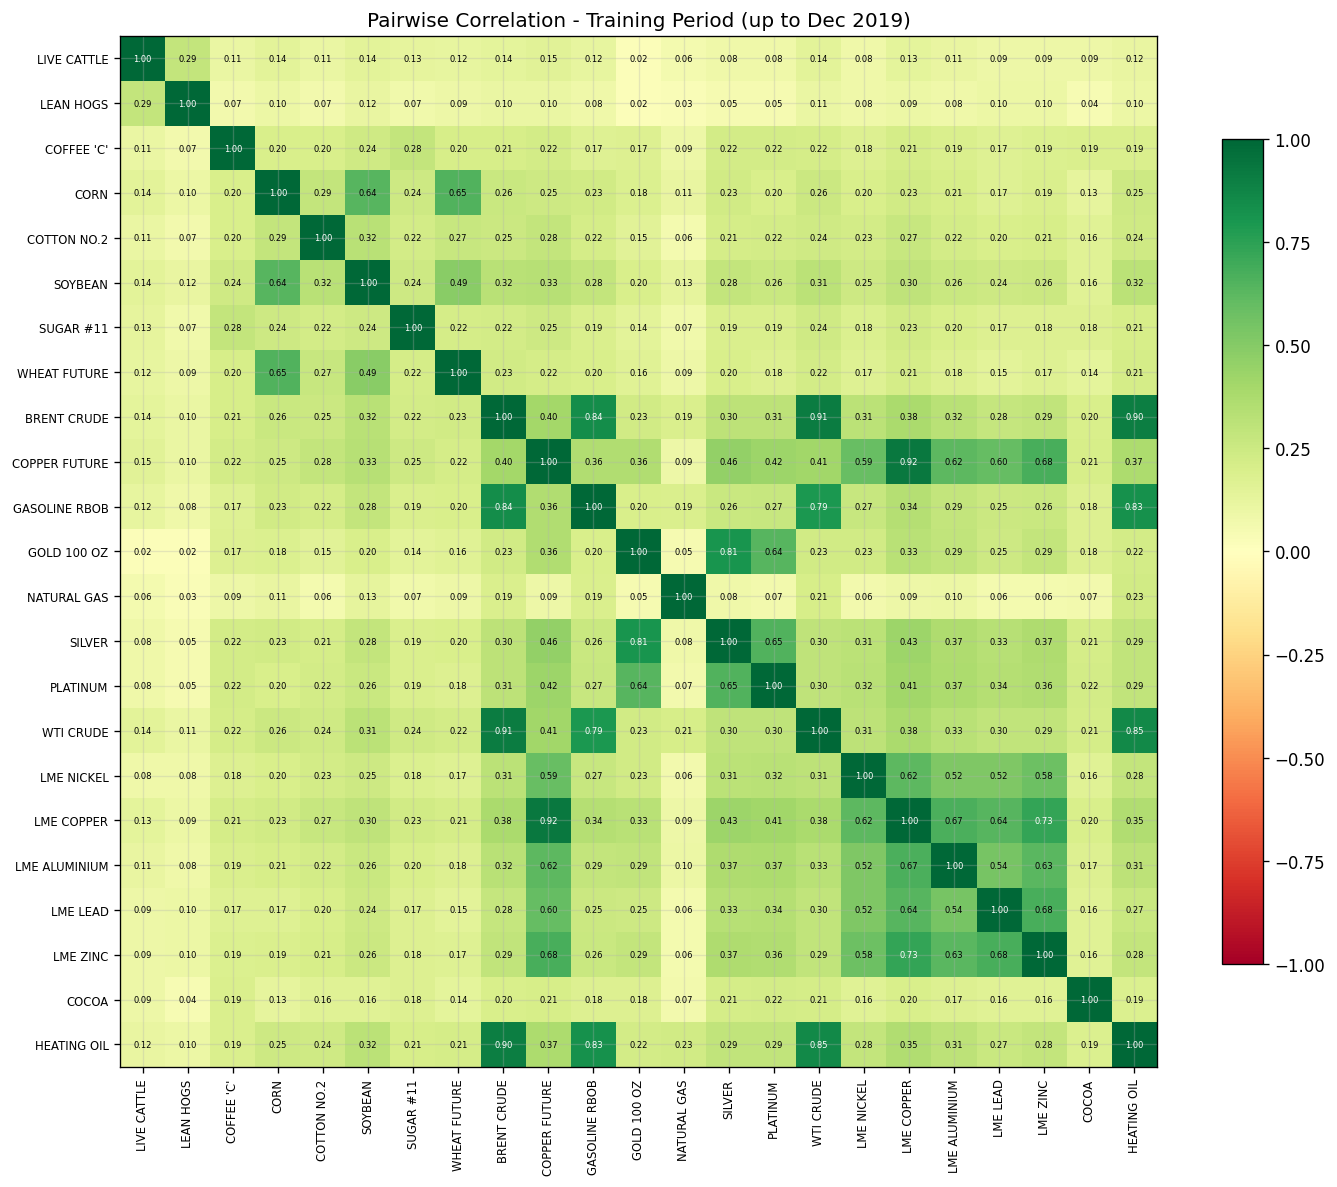

In [50]:
# Use training data only - test-period correlations must not inform model design.
corr = rets.loc[:TRAIN_END].corr()
corr.index   = assets['Commodity'].tolist()
corr.columns = assets['Commodity'].tolist()

# Upper triangle only (k=1 excludes the diagonal of 1.0s).
upper = corr.values[np.triu_indices_from(corr.values, k=1)]
print(f'Mean pairwise correlation : {upper.mean():.3f}')
print(f'Max pairwise correlation  : {upper.max():.3f}')
print(f'Min pairwise correlation  : {upper.min():.3f}')

n   = len(corr)
fig, ax = plt.subplots(figsize=(12, 10))
im  = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(n)); ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(n)); ax.set_yticklabels(corr.index, fontsize=7)

# Annotate each cell with its value; switch to white text where the
# background is dark enough to make black text unreadable.
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{corr.values[i,j]:.2f}',
                ha='center', va='center', fontsize=5,
                color='black' if abs(corr.values[i,j]) < 0.7 else 'white')

ax.set_title('Pairwise Correlation - Training Period (up to Dec 2019)', fontsize=12)
fig.tight_layout()
plt.show()

## 7. Return Distributions - Individual Commodities

Histograms of daily returns let us check two properties that matter for strategy design:

1. **Skewness**: a right-skewed distribution has occasional very large gains (desirable). Negative skew - more common in commodity futures - means frequent small gains but rare large losses. This affects how drawdown controls in Task 2 should be calibrated.

2. **Fat tails (excess kurtosis)**: commodity returns are not normally distributed. The histograms will be narrower in the centre and fatter at the extremes than a Gaussian. This means extreme moves happen more often than a normal model would predict - risk estimates based on volatility alone will systematically understate tail losses.

Colour coding by sector makes it easy to compare shapes: Energy tends to be wider (higher vol) and more right-skewed due to supply shocks.

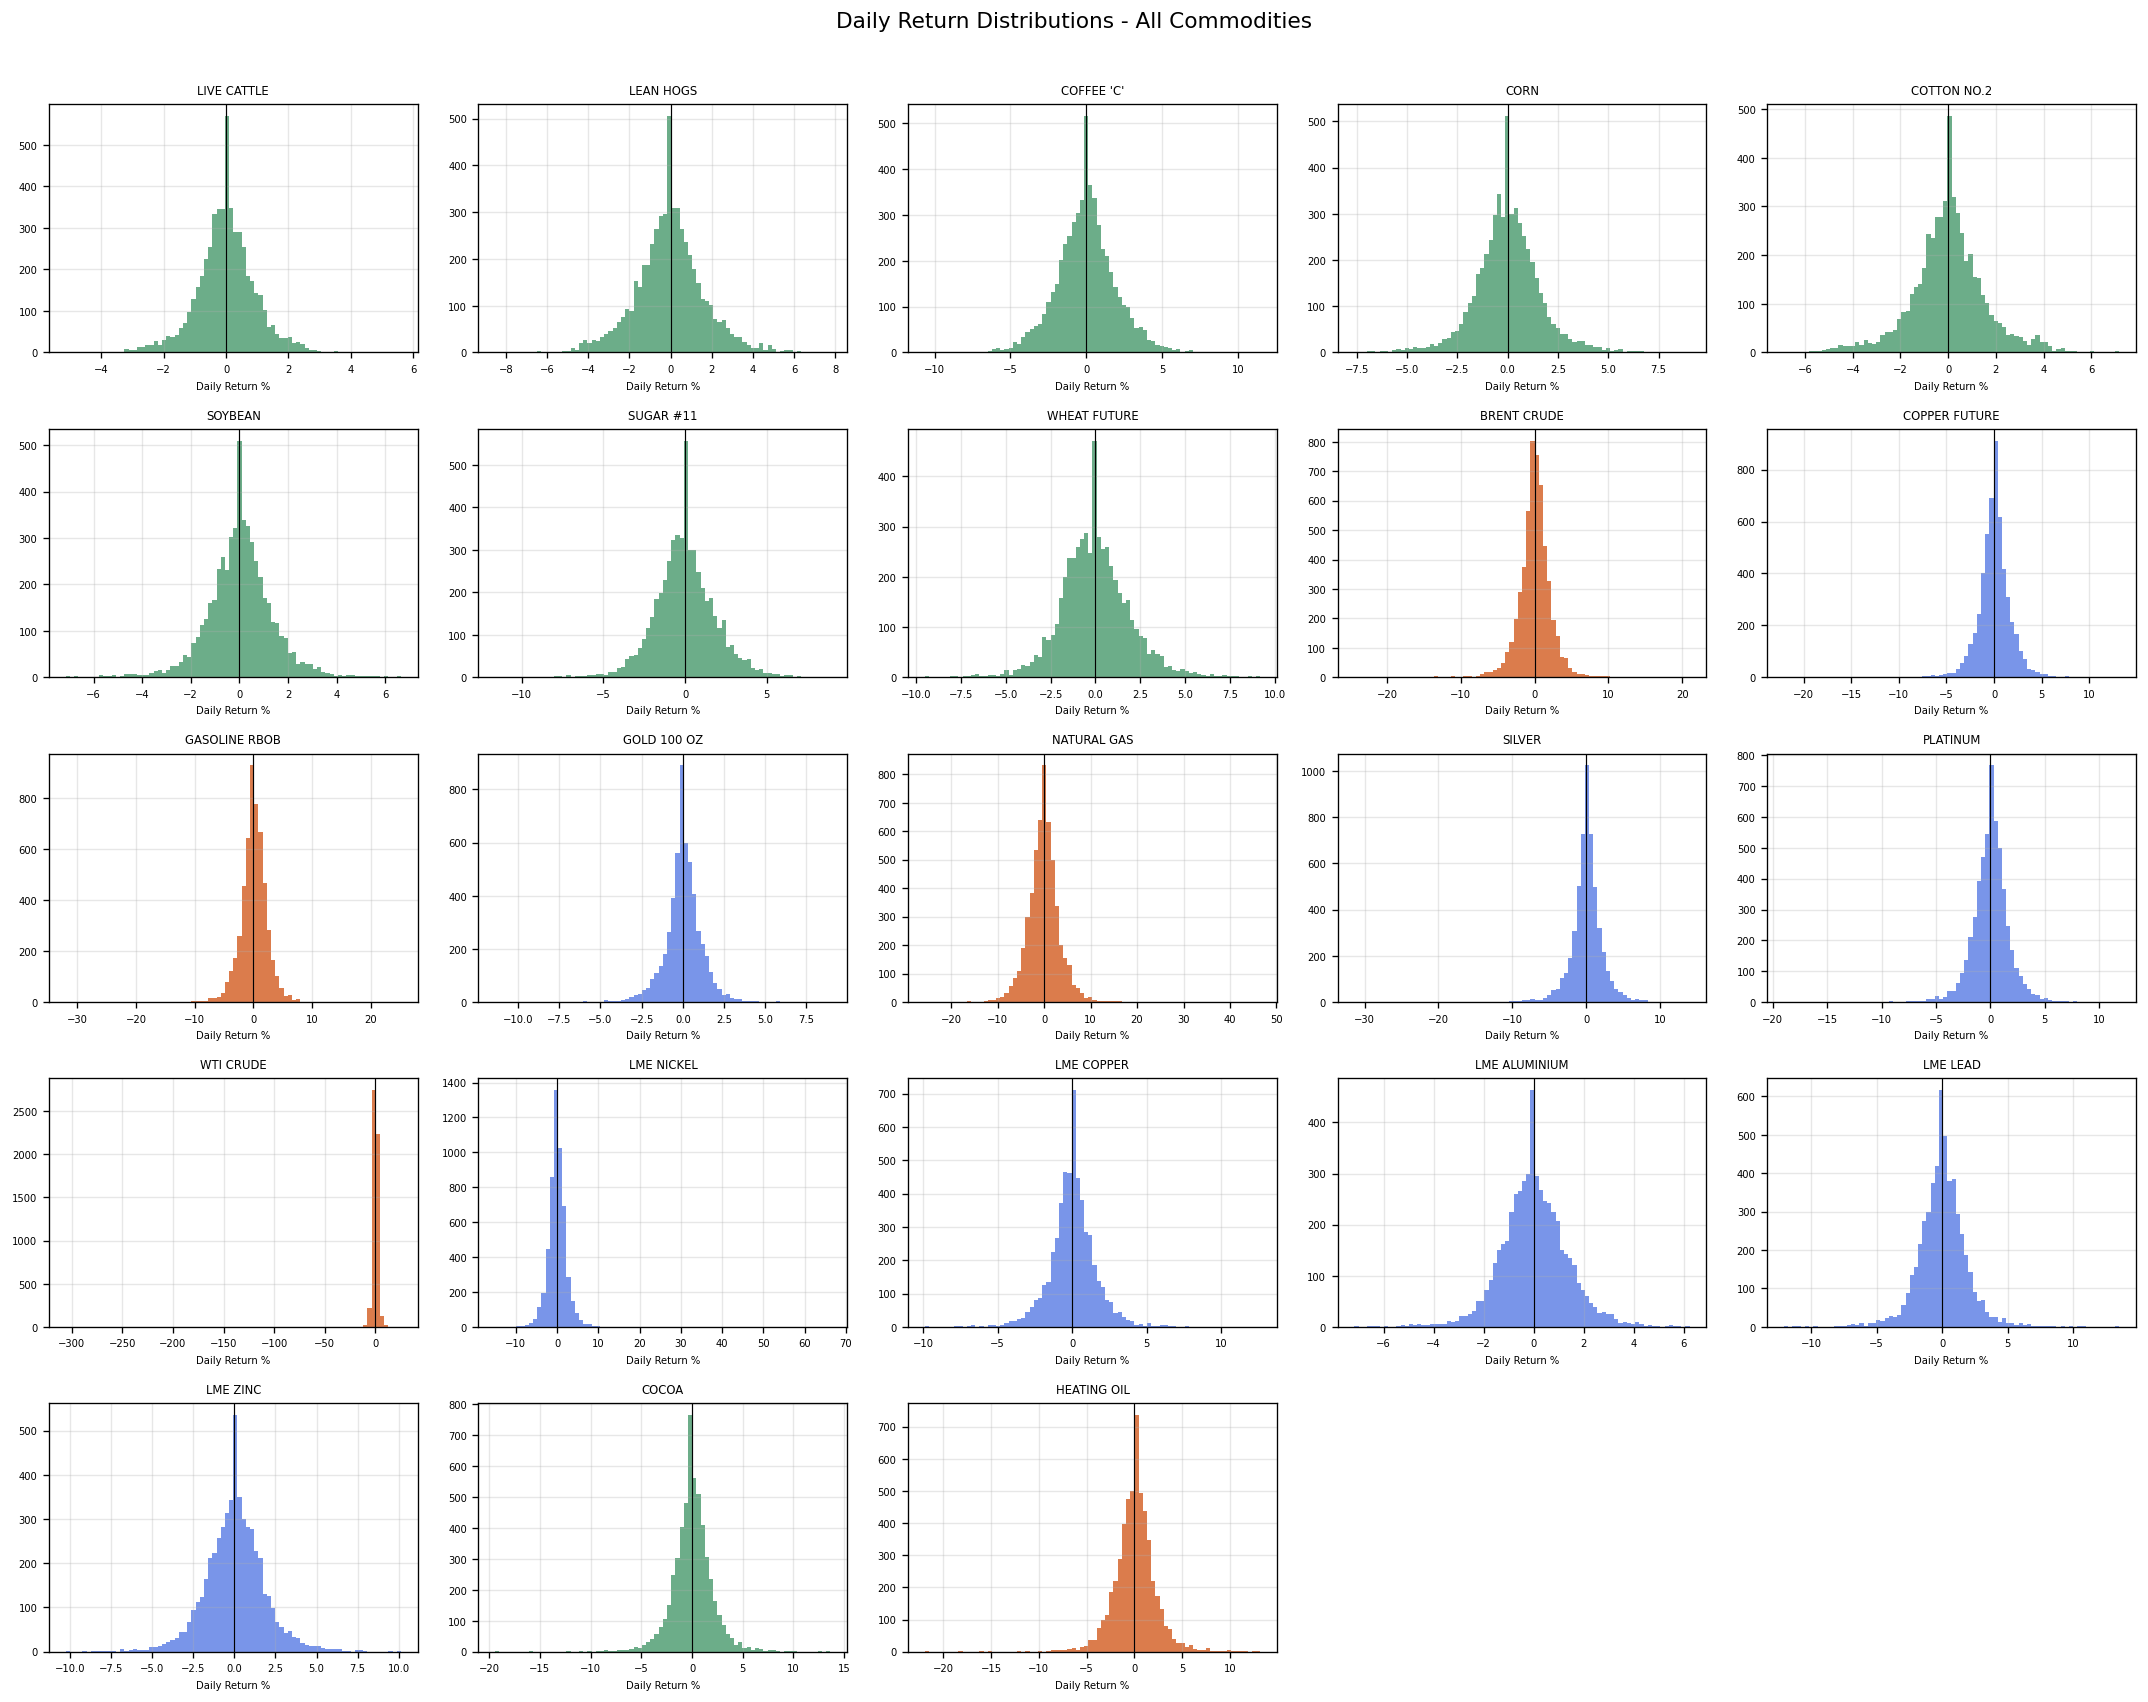

In [51]:
fig, axes = plt.subplots(5, 5, figsize=(18, 14), sharey=False)
axes = axes.flatten()

for i, (col, row) in enumerate(zip(assets['ColName'], assets.itertuples())):
    s  = rets[col].dropna() * 100   # convert to % for a readable x-axis scale
    ax = axes[i]
    ax.hist(s, bins=80, color=sector_colours.get(row.Sector, 'grey'),
            alpha=0.7, edgecolor='none')
    ax.axvline(0, color='black', linewidth=0.7)  # zero-return reference line
    ax.set_title(row.Commodity, fontsize=7)
    ax.set_xlabel('Daily Return %', fontsize=6)
    ax.tick_params(labelsize=6)

# 25 subplot panels for 23 commodities - hide the two unused ones.
for j in range(len(assets), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Daily Return Distributions - All Commodities', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 8. Outlier & Fat-Tail Analysis

The histograms above show the shape of each return distribution, but they don't tell us *how extreme* the extremes are or *how often* they occur. This section quantifies that - which is the analytical basis for deciding whether to winsorise data in later tasks.

Two things to establish:

1. **How large are the biggest single-day moves?** If the largest observations are plausible market events (e.g. a ±15% day in Natural Gas during a supply shock) rather than data errors, they are real risk and should inform position sizing - not be silently removed.

2. **Do extreme moves occur more often than a normal distribution predicts?** Under normality, a 4σ event should occur roughly once every 31,000 trading days (~125 years). If we see several per commodity in a 5,000-day sample, the tails are genuinely fat - and any risk model assuming normality will understate losses.

**Implication for later tasks:**
- **Task 1 (Momentum):** fat tails are real market events; do not winsorise raw returns. Volatility-targeting implicitly shrinks position size after volatile periods.
- **Task 3 (ML):** winsorise features *before* model training to prevent extreme observations from dominating the Lasso/Ridge penalty. Fitted on training data only - never the full dataset.

In [52]:
from scipy import stats as scipy_stats

# -- 1. Largest single-day moves per commodity -----------------------------
# For each commodity we report the 3 largest gains and 3 largest losses
# (as % returns). The goal is to check whether extreme observations are
# plausible market events or data errors.
print('-��' * 70)
print(f'{"Commodity":<20}  {"Worst day":>10}  {"Best day":>10}  {"Date of worst":>12}')
print('-' * 70)
for col in train.columns:
    s    = train[col]
    worst_val  = s.min()
    best_val   = s.max()
    worst_date = s.idxmin().date()
    print(f'{col:<20}  {worst_val*100:>+9.2f}%  {best_val*100:>+9.2f}%  {str(worst_date):>12}')

print('-��' * 70)

-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��-��
Commodity              Worst day    Best day  Date of worst
----------------------------------------------------------------------
LIVE CATTLE               -4.34%      +3.77%    2019-08-13
LEAN HOGS                 -6.39%      +7.59%    2016-09-30
COFFEE 'C'               -10.64%     +11.46%    2008-03-17
CORN                      -7.62%      +9.05%    2013-04-01
COTTON NO.2               -6.88%      +7.17%    2012-06-21
SOYBEAN                   -7.14%      +6.64%    2008-10-10
SUGAR #11                -11.63%      +8.92%    2010-11-12
WHEAT FUTURE              -9.49%      +9.19%    2009-01-12
BRENT CRUDE              -10.36%     +14.63%    2008-10-10
COPPER FUTURE            -10.87%     +12.35%    2008-10-10
GASOLINE RBOB            -10.86%     +13.88%    2008-10-10
GOLD 100 

In [53]:
# -- 2. σ-event frequency vs normal distribution ---------------------------
# Under a normal distribution, the expected number of events beyond each
# threshold in our training sample (3,715 days) is:
#   >3σ: ~7 events    >4σ: ~0.1 events    >5σ: essentially zero
#
# If we observe far more than that, the tails are genuinely fat -
# meaning normal-distribution risk models will understate true drawdown risk.

thresholds = [2, 3, 4, 5]
n_days     = len(train)

# Expected counts under normality (two-tailed)
expected = {t: 2 * (1 - scipy_stats.norm.cdf(t)) * n_days for t in thresholds}

print(f'Training sample: {n_days:,} days')
print(f'\n{"Commodity":<20}', end='')
for t in thresholds:
    print(f'  |r|>{t}σ (exp={expected[t]:.1f})', end='')
print()
print('-' * 80)

for col in train.columns:
    s      = train[col]
    z      = (s - s.mean()) / s.std()   # standardise using full-sample mean/std
    counts = [( abs(z) > t ).sum() for t in thresholds]
    # Flag in red (asterisk) any count that's more than 2x the normal expectation
    row = f'{col:<20}'
    for count, t in zip(counts, thresholds):
        flag = '*' if count > 2 * expected[t] else ' '
        row += f'  {count:>6}{flag}          '
    print(row)

print('-' * 80)
print('* = observed count more than 2× what a normal distribution predicts')

Training sample: 3,715 days

Commodity             |r|>2σ (exp=169.0)  |r|>3σ (exp=10.0)  |r|>4σ (exp=0.2)  |r|>5σ (exp=0.0)
--------------------------------------------------------------------------------
LIVE CATTLE              245                 26*                 2*                 0           
LEAN HOGS                230                 35*                 3*                 0           
COFFEE 'C'               208                 39*                 8*                 2*          
CORN                     224                 55*                11*                 2*          
COTTON NO.2              251                 38*                 6*                 0           
SOYBEAN                  215                 61*                15*                 1*          
SUGAR #11                199                 43*                 9*                 3*          
WHEAT FUTURE             188                 46*                 9*                 0           
BRENT CRUDE       

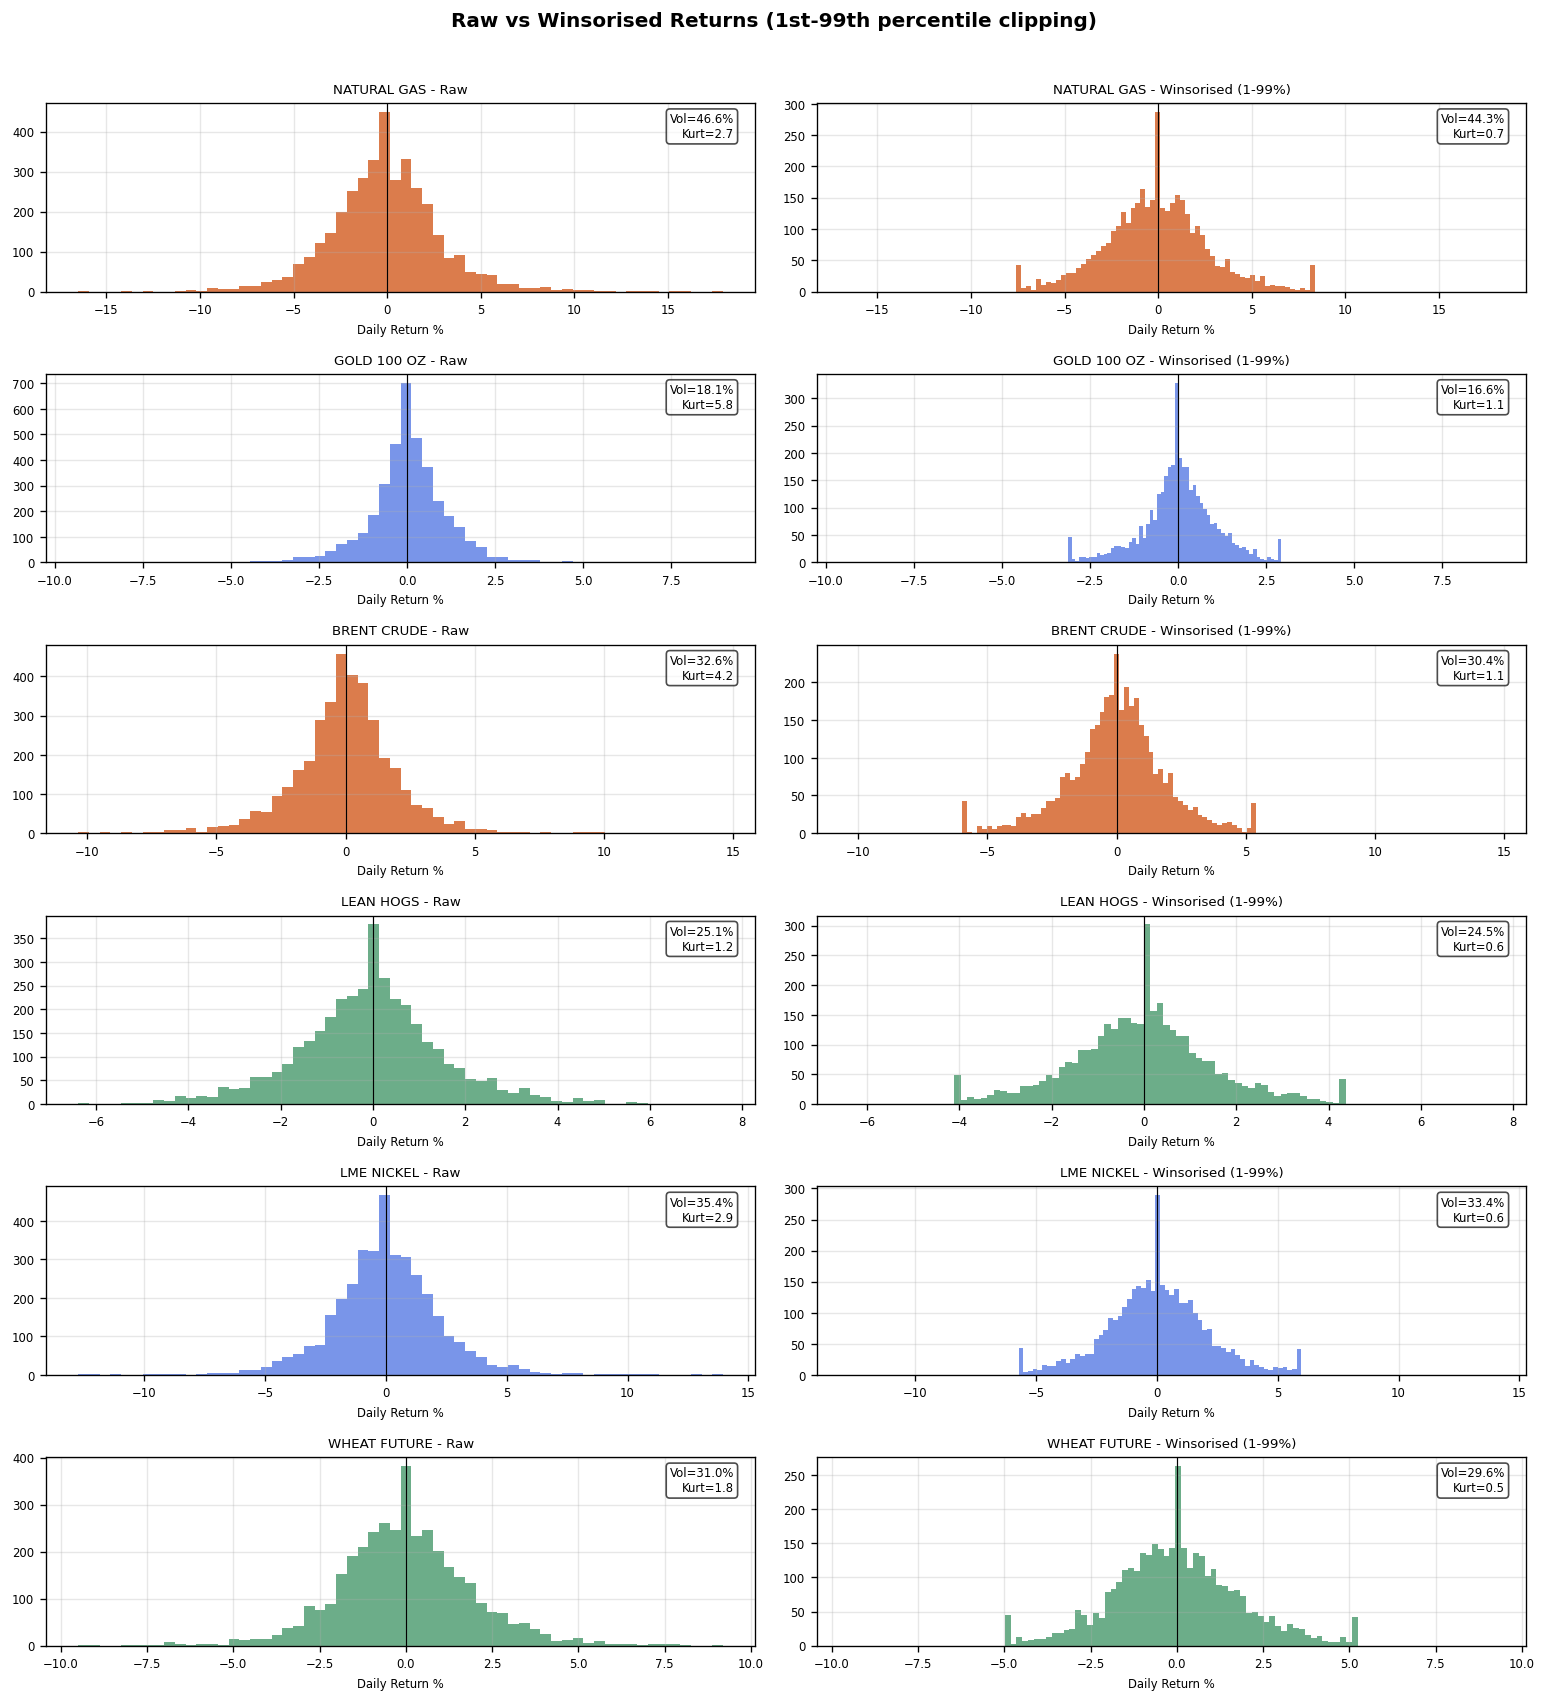


Commodity             Raw Vol%  Win Vol%   Raw Kurt   Win Kurt   Obs clipped
---------------------------------------------------------------------------
NATURAL GAS              46.59     44.28       2.72       0.74            76
GOLD 100 OZ              18.06     16.59       5.83       1.06            76
BRENT CRUDE              32.60     30.37       4.24       1.10            76
LEAN HOGS                25.12     24.49       1.25       0.58            76
LME NICKEL               35.42     33.41       2.89       0.64            76
WHEAT FUTURE             31.03     29.61       1.81       0.47            76


In [54]:
# -- 3. Effect of winsorising on the return distribution -------------------
# We show - for 6 representative commodities - what the distribution looks
# like before and after winsorising at the 1st / 99th percentile.
# This is NOT a recommendation to winsorise the strategy data; it is an
# empirical check of how much the tails influence the overall distribution,
# which informs the feature-engineering decision in Task 3.

showcase = ['NATURAL GAS', 'GOLD 100 OZ', 'BRENT CRUDE',
            'LEAN HOGS',   'LME NICKEL',  'WHEAT FUTURE']

fig, axes = plt.subplots(len(showcase), 2, figsize=(13, 14), sharex='row')
fig.suptitle('Raw vs Winsorised Returns (1st-99th percentile clipping)',
             fontsize=12, fontweight='bold', y=1.01)

for i, col in enumerate(showcase):
    s     = train[col] * 100                        # convert to %
    lo    = np.percentile(s, 1)
    hi    = np.percentile(s, 99)
    s_win = s.clip(lower=lo, upper=hi)              # winsorise

    row   = assets[assets['Commodity'] == col].iloc[0]
    color = sector_colours.get(row['Sector'], 'grey')

    for j, (data, label) in enumerate([(s, 'Raw'), (s_win, 'Winsorised (1-99%)')]):
        ax = axes[i, j]
        ax.hist(data, bins=60, color=color, alpha=0.7, edgecolor='none')
        ax.axvline(0, color='black', linewidth=0.7)
        ax.set_title(f'{col} - {label}', fontsize=8)
        ax.set_xlabel('Daily Return %', fontsize=7)
        ax.tick_params(labelsize=7)

        # Annotate with vol and kurtosis so we can see what changes numerically
        ann_vol  = data.std() * np.sqrt(252)
        kurt_val = data.kurtosis()
        ax.text(0.97, 0.95, f'Vol={ann_vol:.1f}%\nKurt={kurt_val:.1f}',
                transform=ax.transAxes, fontsize=7,
                ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

fig.tight_layout()
plt.show()

# -- Summary table: how much does winsorising change the stats? -------------
print(f'\n{"Commodity":<20}  {"Raw Vol%":>8}  {"Win Vol%":>8}  {"Raw Kurt":>9}  {"Win Kurt":>9}  {"Obs clipped":>12}')
print('-' * 75)
for col in showcase:
    s     = train[col] * 100
    lo, hi = np.percentile(s, 1), np.percentile(s, 99)
    s_win  = s.clip(lo, hi)
    clipped = (( s < lo ) | ( s > hi )).sum()
    print(f'{col:<20}  {s.std()*np.sqrt(252):>8.2f}  {s_win.std()*np.sqrt(252):>8.2f}'
          f'  {s.kurtosis():>9.2f}  {s_win.kurtosis():>9.2f}  {clipped:>12}')